In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [5]:
df = pd.read_csv("data_raw.csv", parse_dates=["timestamp"])
df.sort_values("timestamp", inplace=True)
df.tail()

,timestamp,temperature_raw,growth_raw,humidity_raw,co2_raw
335,2026-02-19 21:08:42,0.979,0.483,0.843,0.146
336,2026-02-19 21:09:43,0.980,0.483,0.849,0.149
337,2026-02-19 21:10:43,0.981,0.483,0.866,0.151
338,2026-02-19 21:11:44,0.983,0.483,0.859,0.154
339,2026-02-19 21:12:44,0.984,0.483,0.860,0.154


<Axes: >

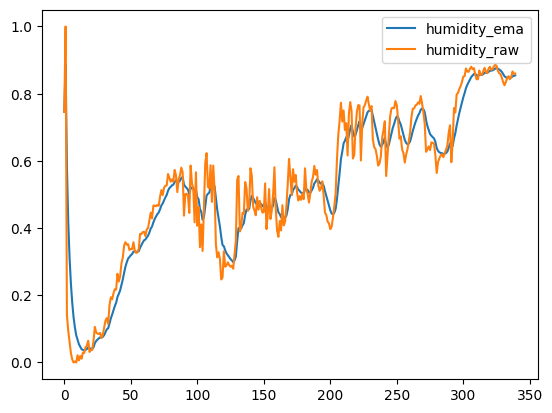

In [15]:
# Exponential moving average

df["humidity_ema"] = df["humidity_raw"].ewm(alpha=0.2).mean()
df[["humidity_ema", "humidity_raw"]].plot()

<Axes: >

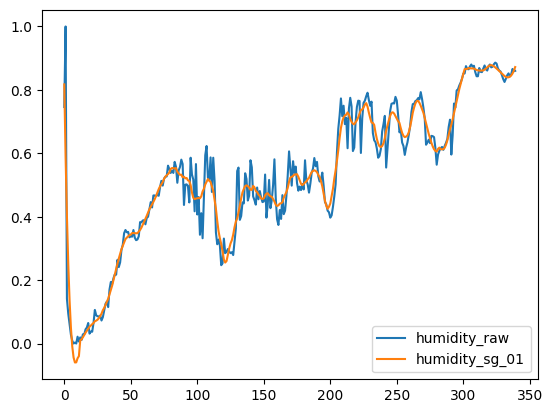

In [11]:
from scipy.signal import savgol_filter

dt = 60  # seconds between samples (adjust if needed)
window_01 = 21  # must be odd
polyorder_01 = 3

df["humidity_sg_01"] = savgol_filter(df["humidity_raw"], window_length=window_01, polyorder=polyorder_01)
df[["humidity_raw","humidity_sg_01"]].plot()

<Axes: >

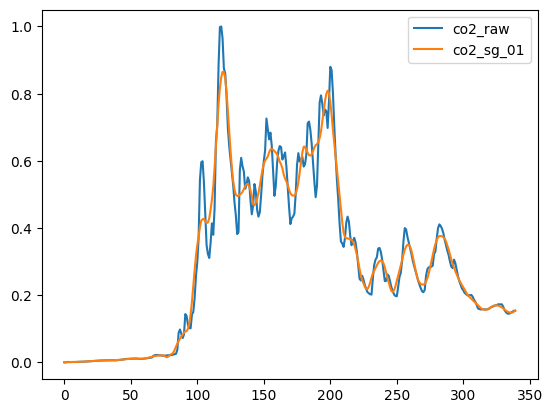

In [9]:
from scipy.signal import savgol_filter

dt = 60  # seconds between samples (adjust if needed)
window_01 = 21  # must be odd
polyorder_01 = 3

df["co2_sg_01"] = savgol_filter(df["co2_raw"], window_length=window_01, polyorder=polyorder_01)
df[["co2_raw", "co2_sg_01"]].plot()

<Axes: >

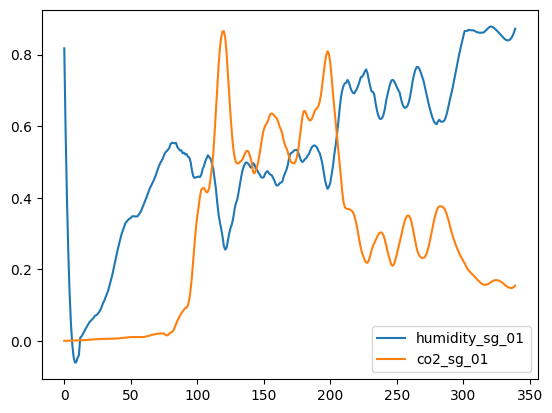

In [10]:
df[["humidity_sg_01", "co2_sg_01"]].plot()